In [16]:
# =========================================
# IMPORT LIBRARY
# =========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings('ignore')

# 1. Menampilkan 5 baris pertama, info, dan statistik deskriptif
df = pd.read_csv('Sales-Marketing customer dataset.csv')
print("--- 5 Baris Pertama ---")
display(df.head())

print("\n--- Informasi Dataset ---")
print(df.info())

print("\n--- Statistik Deskriptif ---")
display(df.describe())

df['churn'].value_counts(normalize=True) * 100

--- 5 Baris Pertama ---


,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0



--- Informasi Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  object 
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  object 
 4   city                        15000 non-null  object 
 5   signup_date                 15000 non-null  object 
 6   last_purchase_date          15000 non-null  object 
 7   acquisition_channel         15000 non-null  object 
 8   device_type                 15000 non-null  object 
 9   subscription_type           15000 non-null  object 
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float64
 13  page

,customer_id,age,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,discount_used,support_tickets,refund_requested,delivery_delay_days,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
count,15000.000000,13800.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,13950.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,14298.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,17500.500000,35.203913,0.304467,15.000933,8.020805,4.002901,0.496278,0.251231,524.357397,60.080882,0.494467,1.995600,0.147667,2.981333,3.588754,4.968667,17.575238,1235.698200,6.975133,0.153200
std,4330.271354,10.334384,0.460197,3.892704,2.991499,1.479846,0.290108,0.144689,467.050070,24.746203,0.499986,1.421214,0.354781,1.720537,1.088703,3.155495,7.183437,657.521849,4.323443,0.360192
min,10001.000000,-4.000000,0.000000,3.000000,0.006095,0.007845,0.000000,0.000000,0.267291,0.071596,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,5.000000,0.368886,0.000000,0.000000
25%,13750.750000,28.000000,0.000000,12.000000,5.974555,2.989150,0.240000,0.130000,300.432074,43.032470,0.000000,1.000000,0.000000,2.000000,3.000000,2.000000,11.380000,741.301251,3.000000,0.000000
50%,17500.500000,35.000000,0.000000,15.000000,7.991907,3.996992,0.500000,0.250000,498.843859,60.108827,0.000000,2.000000,0.000000,3.000000,4.000000,5.000000,17.630000,1216.210685,7.000000,0.000000
75%,21250.250000,42.000000,1.000000,18.000000,10.059986,5.014406,0.750000,0.380000,702.396635,76.888445,1.000000,3.000000,0.000000,4.000000,4.000000,8.000000,23.770000,1677.860399,11.000000,0.000000
max,25000.000000,95.000000,1.000000,31.000000,19.123716,10.843172,1.000000,0.500000,15910.431879,154.554696,1.000000,9.000000,1.000000,11.000000,5.000000,10.000000,30.000000,3767.490455,14.000000,1.000000


,proportion
churn,
0,84.68
1,15.32


Ketidakseimbangan Kelas (Class Imbalance) pada Target churn

0 (Tetap Berlangganan): 84,68% (12.702 pelanggan)

1 (Churn/Berhenti): 15,32% (2.298 pelanggan)

Insight: Data ini mengalami imbalance. Implikasinya, Anda tidak boleh hanya mengandalkan metrik Accuracy saat mengevaluasi model nanti, melainkan harus berfokus pada F1-Score atau Recall agar model sensitif dalam mendeteksi pelanggan yang benar-benar akan churn.

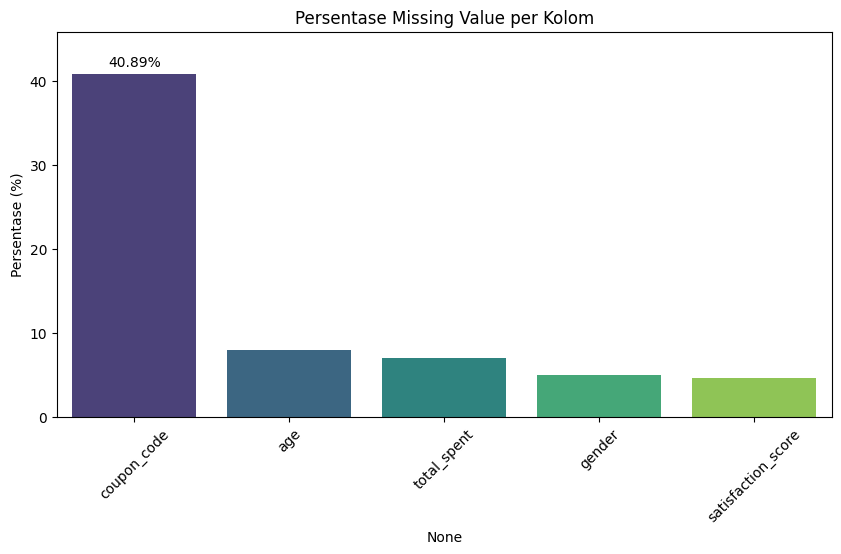

In [17]:
# 2. Menghitung persentase nilai kosong
missing_pct = df.isnull().mean() * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

# 3. Membuat visualisasi
plt.figure(figsize=(10, 5))

# Perhatikan bagian ini: tambahkan 'ax =' di depan sns.barplot
ax = sns.barplot(x=missing_pct.index, y=missing_pct.values, palette='viridis')

# BARIS INI YANG BERTUGAS MEMUNCULKAN ANGKA AKURAT
ax.bar_label(ax.containers[0], fmt='%.2f%%', padding=3, fontsize=10)

plt.title('Persentase Missing Value per Kolom')
plt.ylabel('Persentase (%)')
plt.xticks(rotation=45)

# Baris ini untuk memberi ruang di atas grafik agar angkanya tidak terpotong teks judul
plt.ylim(0, max(missing_pct.values) + 5)

plt.show()

Analisis Nilai yang Hilang (Missing Values)
Terdapat 5 kolom yang memiliki missing value. Anda harus memvisualisasikannya dengan diagram batang sesuai instruksi soal:

coupon_code: Hilang 40,89% (6.133 baris). Insight: Ini wajar karena tidak semua pelanggan menggunakan kupon belanja. Solusi saat preprocessing nanti: isi dengan kategori baru seperti 'No_Coupon'.

age: Hilang 8,00% (1.200 baris). Solusi: isi dengan nilai median atau mean.

total_spent: Hilang 7,00% (1.050 baris). Solusi: isi dengan nilai 0 atau median.

gender: Hilang 4,92% (738 baris). Solusi: isi dengan modus ('Male'/'Female') atau buat kategori 'Unknown'.

satisfaction_score: Hilang 4,68% (702 baris). Solusi: isi dengan nilai median.

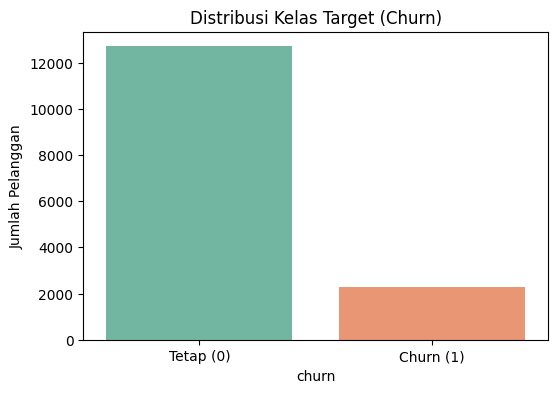

In [18]:
# 3. Visualisasi distribusi variabel target (Churn)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='churn', palette='Set2')
plt.title('Distribusi Kelas Target (Churn)')
plt.xticks([0, 1], ['Tetap (0)', 'Churn (1)'])
plt.ylabel('Jumlah Pelanggan')
plt.show()

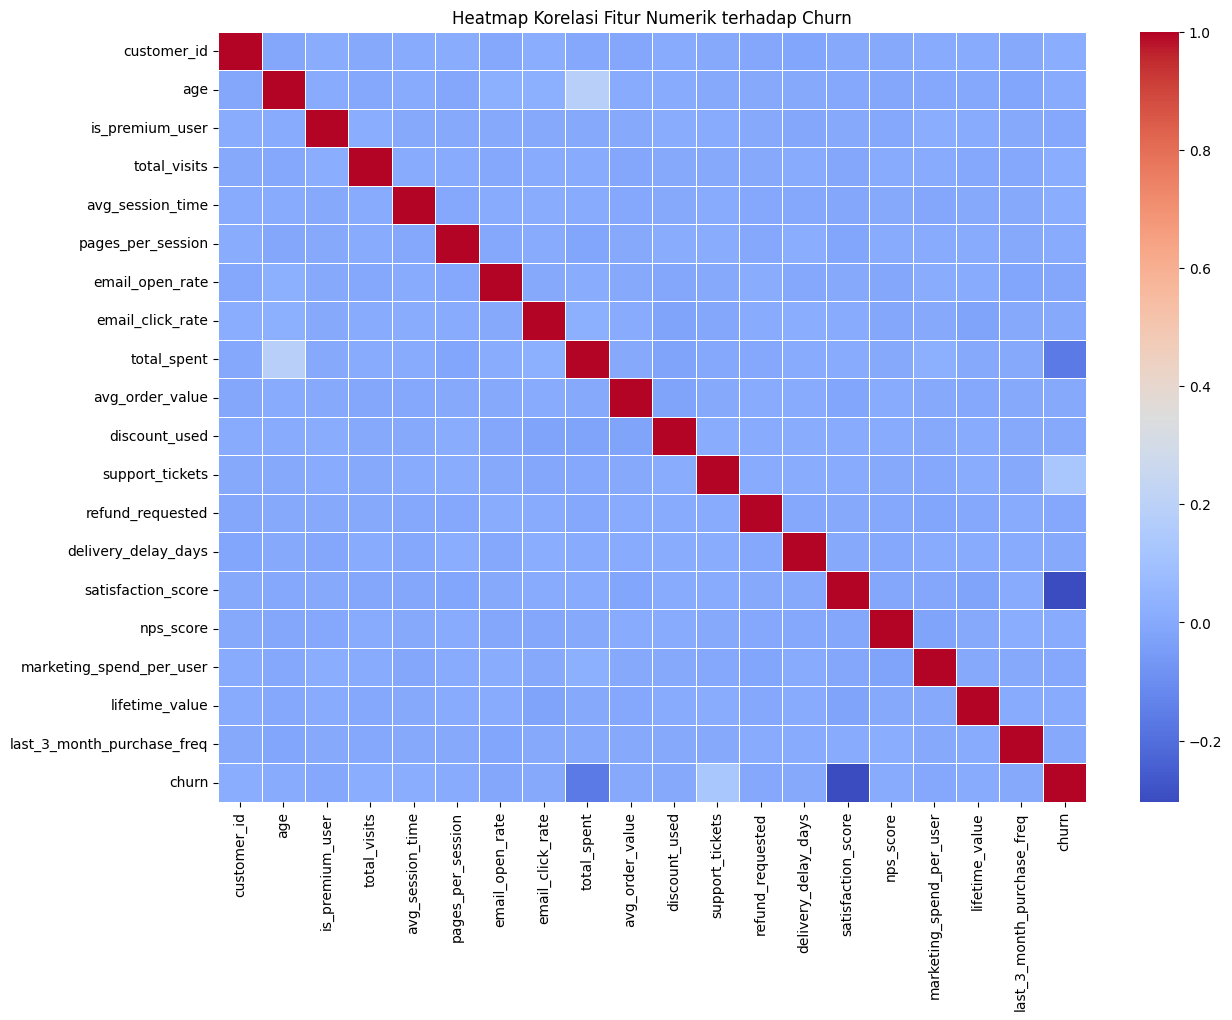

In [19]:
# 4. Heatmap korelasi fitur numerik
plt.figure(figsize=(14, 10))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap Korelasi Fitur Numerik terhadap Churn')
plt.show()

Hubungan & Korelasi Fitur Terhadap Churn (Lihat Heatmap)
Berdasarkan koefisien korelasi numerik, fitur yang paling memengaruhi keputusan pelanggan untuk churn adalah:

satisfaction_score (-0.30): Memiliki korelasi negatif terkuat. Artinya, semakin rendah skor kepuasan pelanggan, peluang mereka untuk churn akan semakin tinggi.

total_spent (-0.16): Korelasi negatif. Pelanggan yang total pengeluarannya sudah besar cenderung lebih loyal dan jarang churn.

support_tickets (+0.12): Korelasi positif tertinggi. Semakin sering pelanggan mengajukan tiket komplain/bantuan, semakin besar kemungkinan mereka kecewa dan memilih churn.

Persiapan Data Modeling

In [20]:
# =========================================
# FEATURE & TARGET
# =========================================

X = df.drop(columns=['churn'])

y = df['churn']

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (15000, 29)
Target Shape : (15000,)


In [21]:
# =========================================
# ENCODING CATEGORICAL FEATURES
# =========================================

X = pd.get_dummies(X, drop_first=True)

print("Encoded Shape :", X.shape)

Encoded Shape : (15000, 1842)


In [22]:
# =========================================
# HANDLE MISSING VALUE
# =========================================

# Numerical columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns

# Categorical columns
cat_cols = X.select_dtypes(include=['object']).columns

# Fill numerical missing values with median
for col in num_cols:
    X[col] = X[col].fillna(X[col].median())

# Fill categorical missing values with mode
for col in cat_cols:
    X[col] = X[col].fillna(X[col].mode()[0])

print("Missing values after handling:")
print(X.isnull().sum().sum())

Missing values after handling:
0


In [23]:
# =========================================
# TRAIN TEST SPLIT
# =========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train Shape :", X_train.shape)
print("Test Shape :", X_test.shape)

Train Shape : (12000, 1842)
Test Shape : (3000, 1842)


In [24]:
# =========================================
# LOGISTIC REGRESSION
# =========================================

lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

In [25]:
# =========================================
# RANDOM FOREST
# =========================================

rf_model = RandomForestClassifier(
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [26]:
# =========================================
# VOTING CLASSIFIER
# =========================================

knn = KNeighborsClassifier()

svm = SVC(probability=True)

voting_model = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression()),
        ('knn', knn),
        ('svm', svm)
    ],
    voting='soft'
)

voting_model.fit(X_train, y_train)

voting_pred = voting_model.predict(X_test)

In [27]:
# =========================================
# EVALUATION FUNCTION
# =========================================

def evaluate_model(y_true, y_pred, model_name):

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(y_true, y_pred)

    recall = recall_score(y_true, y_pred)

    f1 = f1_score(y_true, y_pred)

    print(f"\n===== {model_name} =====")

    print("Accuracy :", accuracy)
    print("Precision :", precision)
    print("Recall :", recall)
    print("F1-Score :", f1)

    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f'Confusion Matrix - {model_name}')

    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.show()


===== Logistic Regression =====
Accuracy : 0.849
Precision : 0.5376344086021505
Recall : 0.10869565217391304
F1-Score : 0.18083182640144665

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.98      0.92      2540
           1       0.54      0.11      0.18       460

    accuracy                           0.85      3000
   macro avg       0.70      0.55      0.55      3000
weighted avg       0.81      0.85      0.80      3000



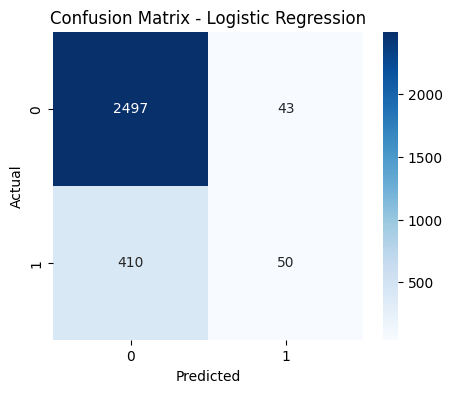


===== Random Forest =====
Accuracy : 0.8453333333333334
Precision : 0.47297297297297297
Recall : 0.07608695652173914
F1-Score : 0.13108614232209737

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.98      0.92      2540
           1       0.47      0.08      0.13       460

    accuracy                           0.85      3000
   macro avg       0.66      0.53      0.52      3000
weighted avg       0.80      0.85      0.79      3000



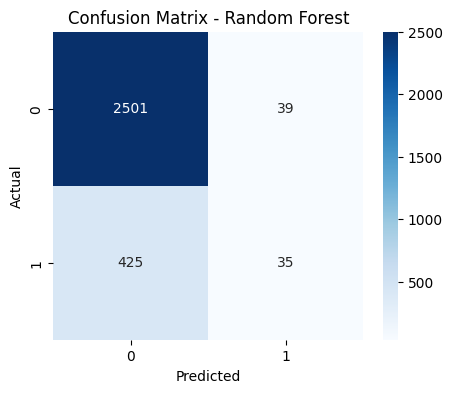


===== Voting Classifier =====
Accuracy : 0.8466666666666667
Precision : 0.5
Recall : 0.008695652173913044
F1-Score : 0.017094017094017096

Classification Report:

              precision    recall  f1-score   support

           0       0.85      1.00      0.92      2540
           1       0.50      0.01      0.02       460

    accuracy                           0.85      3000
   macro avg       0.67      0.50      0.47      3000
weighted avg       0.79      0.85      0.78      3000



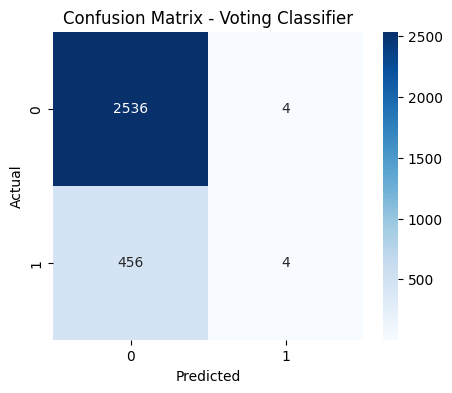

In [28]:
# =========================================
# MODEL EVALUATION
# =========================================

evaluate_model(y_test, lr_pred, "Logistic Regression")

evaluate_model(y_test, rf_pred, "Random Forest")

evaluate_model(y_test, voting_pred, "Voting Classifier")

In [29]:
# =========================================
# MODEL COMPARISON
# =========================================

results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'Voting Classifier'
    ],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, voting_pred)
    ],
    'Precision': [
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, voting_pred)
    ],
    'Recall': [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, voting_pred)
    ],
    'F1-Score': [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, voting_pred)
    ]
})

results.sort_values(by='F1-Score', ascending=False)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.849000,0.537634,0.108696,0.180832
1,Random Forest,0.845333,0.472973,0.076087,0.131086
2,Voting Classifier,0.846667,0.500000,0.008696,0.017094
